<a href="https://colab.research.google.com/github/ChariteshReddyPatlolla/stock-price-predector/blob/main/stock_pricebasic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

In [ ]:
apple=yf.Ticker("AAPL")


In [ ]:
import yfinance as yf

# Load 5 years of historical data for Apple
df = yf.download('AAPL', start='2018-01-01', end='2025-06-30')
# df = df[['Close']]


/tmp/ipython-input-39-1780405538.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2018-01-01', end='2025-06-30')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.426823,40.436212,39.722768,39.933986,102223600
2018-01-03,40.419781,40.964251,40.356418,40.490187,118071600
2018-01-04,40.607536,40.710798,40.384586,40.492539,89738400
2018-01-05,41.069851,41.156683,40.612216,40.703743,94640000
2018-01-08,40.917313,41.213014,40.818742,40.917313,82271200


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout


In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Create sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len)

# # Reshape X for LSTM [samples, time_steps, features]
# X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [ ]:
X.shape

(2653, 60)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Predicted price

from keras import metrics

model.compile(optimizer='adam', loss='mean_squared_error', metrics=[metrics.RootMeanSquaredError()])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0319 - root_mean_squared_error: 0.1684 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0431
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0025 - root_mean_squared_error: 0.0500 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0381
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0019 - root_mean_squared_error: 0.0431 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0436
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0018 - root_mean_squared_error: 0.0422 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0526
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0021 - root_mean_squared_error: 0.0458 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0360
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0017 - root_mean_squared_error: 0.0414 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0450
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss:

In [ ]:
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted.reshape(-1, 1))
actual = scaler.inverse_transform(y_test.reshape(-1, 1))


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


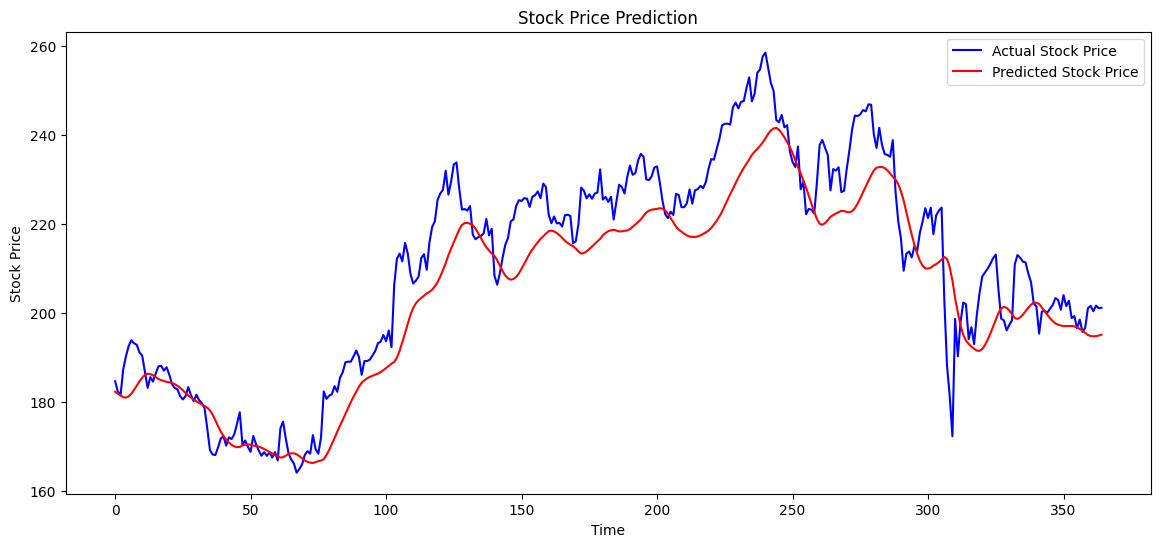

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(actual, color='blue', label='Actual Stock Price')
plt.plot(predicted, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


RMSE: 7.303737371087084
R² Score: 0.860141510212669


/tmp/ipython-input-23-3465700789.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2018-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0671 - val_loss: 0.0084
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0051 - val_loss: 0.0013
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0031 - val_loss: 0.0021
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0027 - val_loss: 0.0045
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0027 - val_loss: 0.0036
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0

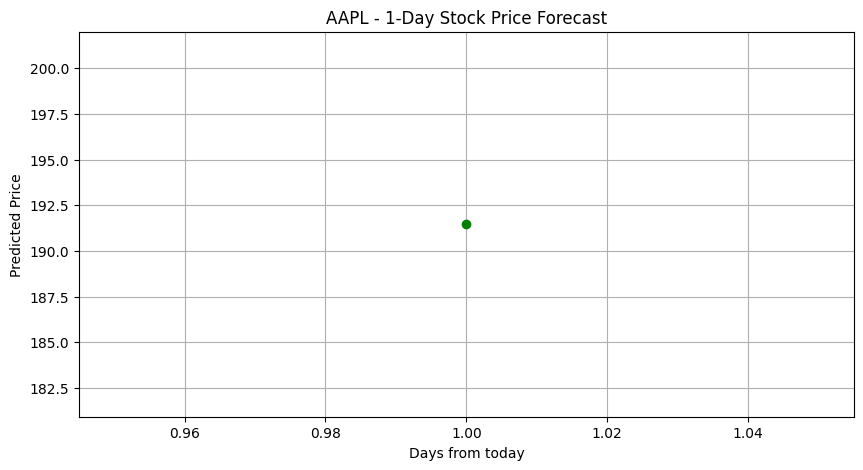

In [ ]:
# Step 1: Install and import necessary libraries
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Step 2: Download stock data
ticker = 'AAPL'  # You can change to any stock symbol
df = yf.download(ticker, start='2018-01-01', end='2023-12-31')
df = df[['Close']]

# Step 3: Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Step 4: Create sequences for training
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Step 5: Train-test split
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Step 6: Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_len, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 8: Predict future n days
def predict_n_days_ahead(model, data, n_days, scaler):
    last_60_days = data[-60:]
    input_seq = last_60_days.reshape(1, -1)
    temp_input = list(input_seq[0])
    predictions = []

    for _ in range(n_days):
        if len(temp_input) > 60:
            temp_input = temp_input[1:]
        input_arr = np.array(temp_input).reshape(1, 60, 1)
        pred = model.predict(input_arr, verbose=0)
        predictions.append(pred[0][0])
        temp_input.append(pred[0][0])

    # Inverse transform to original scale
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return predictions

# Step 9: Take user input and predict
n_days = int(input("Enter how many days ahead you want to predict: "))
future_prices = predict_n_days_ahead(model, scaled_data, n_days, scaler)

# Step 10: Plot the forecast
plt.figure(figsize=(10,5))
plt.plot(range(1, n_days+1), future_prices, marker='o', color='green')
plt.title(f'{ticker} - {n_days}-Day Stock Price Forecast')
plt.xlabel('Days from today')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()


Enter how many days ahead you want to predict: 10


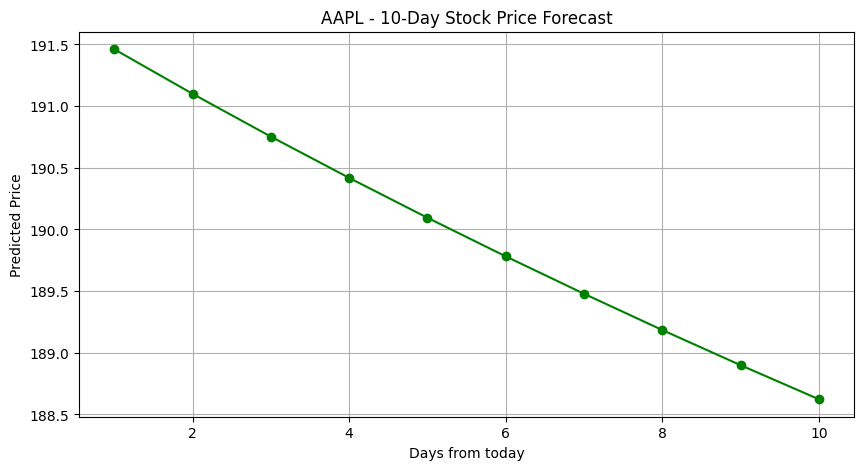

In [ ]:
# Step 9: Take user input and predict
n_days = int(input("Enter how many days ahead you want to predict: "))
future_prices = predict_n_days_ahead(model, scaled_data, n_days, scaler)

# Step 10: Plot the forecast
plt.figure(figsize=(10,5))
plt.plot(range(1, n_days+1), future_prices, marker='o', color='green')
plt.title(f'{ticker} - {n_days}-Day Stock Price Forecast')
plt.xlabel('Days from today')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

Enter how many days ahead you want to predict: 20


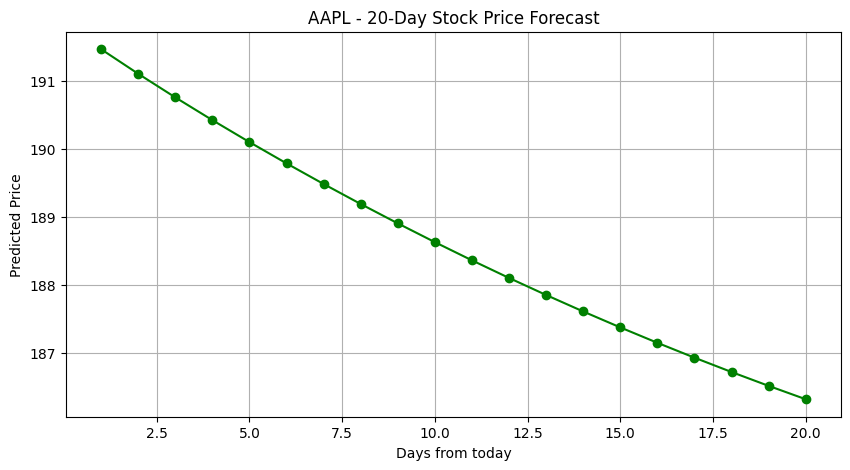

In [ ]:
# Step 9: Take user input and predict
n_days = int(input("Enter how many days ahead you want to predict: "))
future_prices = predict_n_days_ahead(model, scaled_data, n_days, scaler)

# Step 10: Plot the forecast
plt.figure(figsize=(10,5))
plt.plot(range(1, n_days+1), future_prices, marker='o', color='green')
plt.title(f'{ticker} - {n_days}-Day Stock Price Forecast')
plt.xlabel('Days from today')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

/tmp/ipython-input-1-1474586665.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period='7d', interval='1m')  # 1-minute interval
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0184 - val_loss: 0.0028
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0013 - val_loss: 0.0072
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 9.4213e-04 - val_loss: 0.0011
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0013 - val_loss: 5.3248e-04
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 8.6245e-04 - val_loss: 5.1880e-04
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 9.1962e-04 - val_loss: 4.5811e-04
Enter how many minutes ahead you want to predict: 20


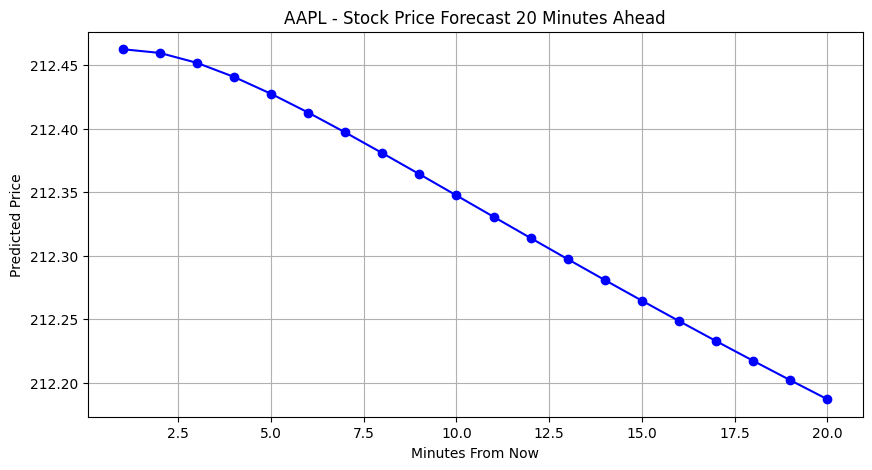

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Step 2: Load minute-level data (last 7 days only)
ticker = 'AAPL'
df = yf.download(tickers=ticker, period='7d', interval='1m')  # 1-minute interval
df = df[['Close']]
df.dropna(inplace=True)

# Step 3: Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Step 4: Create sequences (60 minutes as history)
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_len = 60  # past 60 minutes to predict next
X, y = create_sequences(scaled_data, seq_len)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 5: Train-test split
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Step 6: Build and train LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_len, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Step 7: Predict n minutes ahead
def predict_n_minutes_ahead(model, data, n_minutes, scaler):
    last_seq = data[-60:]
    temp_input = list(last_seq.flatten())
    predictions = []

    for _ in range(n_minutes):
        input_arr = np.array(temp_input[-60:]).reshape(1, 60, 1)
        pred = model.predict(input_arr, verbose=0)
        predictions.append(pred[0][0])
        temp_input.append(pred[0][0])

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return predictions

# Step 8: User input and prediction
n_minutes = int(input("Enter how many minutes ahead you want to predict: "))
future_prices = predict_n_minutes_ahead(model, scaled_data, n_minutes, scaler)

# Step 9: Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_minutes + 1), future_prices, marker='o', color='blue')
plt.title(f"{ticker} - Stock Price Forecast {n_minutes} Minutes Ahead")
plt.xlabel('Minutes From Now')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()


Enter how many minutes ahead you want to predict: 60


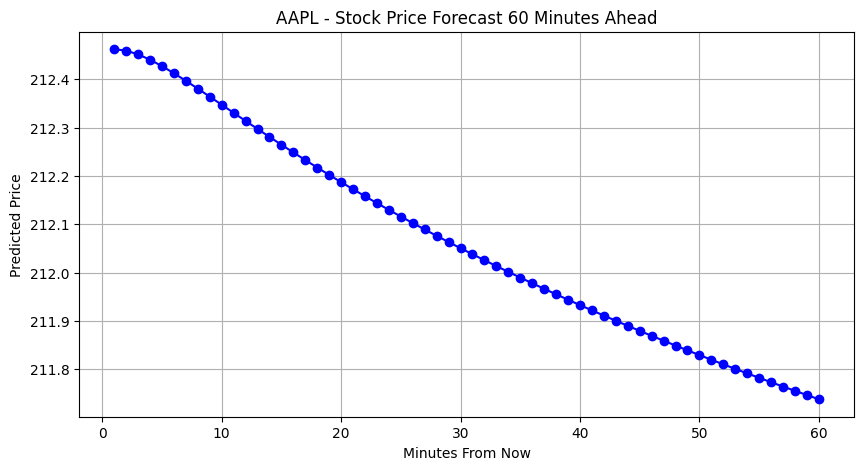

In [ ]:
n_minutes = int(input("Enter how many minutes ahead you want to predict: "))
future_prices = predict_n_minutes_ahead(model, scaled_data, n_minutes, scaler)

# Step 9: Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_minutes + 1), future_prices, marker='o', color='blue')
plt.title(f"{ticker} - Stock Price Forecast {n_minutes} Minutes Ahead")
plt.xlabel('Minutes From Now')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()


In [ ]:
df = yf.download(tickers=ticker, period='7d', interval='1m')
df.head()

/tmp/ipython-input-29-3604016747.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period='7d', interval='1m')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2025-06-24 13:30:00+00:00,201.885803,202.779999,201.440002,202.589996,2507586
2025-06-24 13:31:00+00:00,201.820007,202.380005,201.639999,201.861603,319404
2025-06-24 13:32:00+00:00,202.419998,202.669998,201.809998,201.860001,468576
2025-06-24 13:33:00+00:00,202.070007,202.500000,201.940002,202.470001,287783
2025-06-24 13:34:00+00:00,202.240005,202.359894,201.889999,202.059998,162603


/tmp/ipython-input-41-455855916.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,468 (119.02 KB)

 Trainable params: 30,468 (119.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0712 - val_loss: 0.0059
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0021 - val_loss: 0.0029
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 9.4244e-04 - val_loss: 0.0025
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 8.0766e-04 - val_loss: 0.0038
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 9.3784e-04 - val_loss: 0.0023
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 7.5875e-04 - val_loss: 0.0022
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 6.2564e-04 - val_loss: 0.0023
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 6.7204e-04 - val_loss: 0.0022
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.3289e-04 - val_loss: 0.0027
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 7.3638e-04 - val_loss: 0.0019
Epoch 12/20
30/30 ━━━━━━━━━━━━━

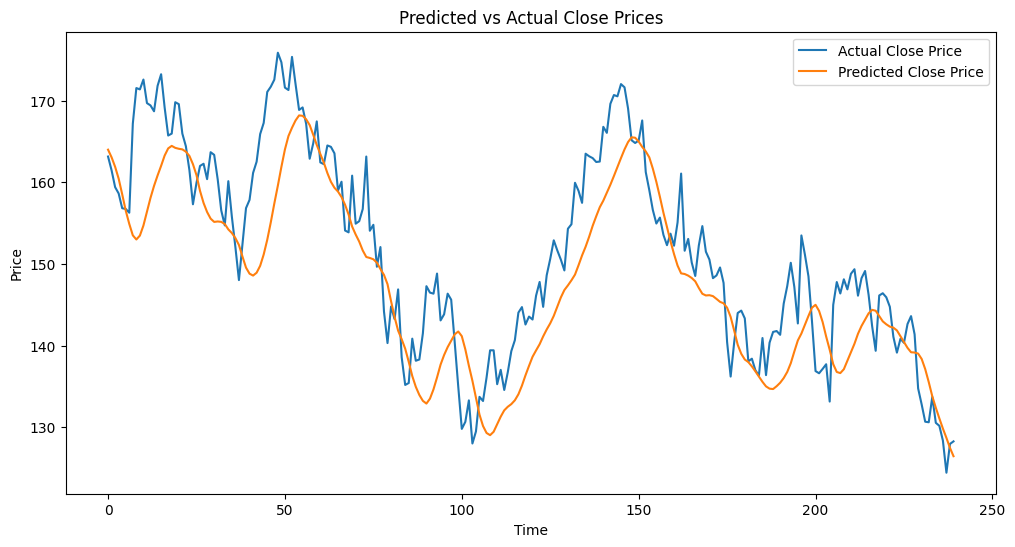

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. Load historical stock data
ticker = "AAPL"
df = yf.download(ticker, start="2018-01-01", end="2023-01-01")

# Use only required columns
df = df[["Open", "High", "Low", "Close", "Volume"]]

# 2. Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 3. Create sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0:4])  # Open, High, Low, Close
    return np.array(X), np.array(y)

seq_len = 60
X, y = create_sequences(scaled_data, seq_len)

# 4. Train/test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# 5. Build the LSTM model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(LSTM(32))
model.add(Dense(4))  # Predicting 4 values: Open, High, Low, Close

model.compile(optimizer='adam', loss='mse')
model.summary()

# 6. Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# 7. Make predictions
predicted = model.predict(X_test)

# Inverse transform predictions
full_scaler = MinMaxScaler()
full_scaler.fit(df)  # to inverse-transform properly
predicted_full = np.zeros((predicted.shape[0], scaled_data.shape[1]))
predicted_full[:, 0:4] = predicted
predicted_prices = full_scaler.inverse_transform(predicted_full)[:, 0:4]

actual_full = np.zeros((y_test.shape[0], scaled_data.shape[1]))
actual_full[:, 0:4] = y_test
actual_prices = full_scaler.inverse_transform(actual_full)[:, 0:4]

# 8. Plot actual vs predicted Close prices
plt.figure(figsize=(12,6))
plt.plot(actual_prices[:, 3], label='Actual Close Price')     # Close is index 3
plt.plot(predicted_prices[:, 3], label='Predicted Close Price')
plt.title('Predicted vs Actual Close Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


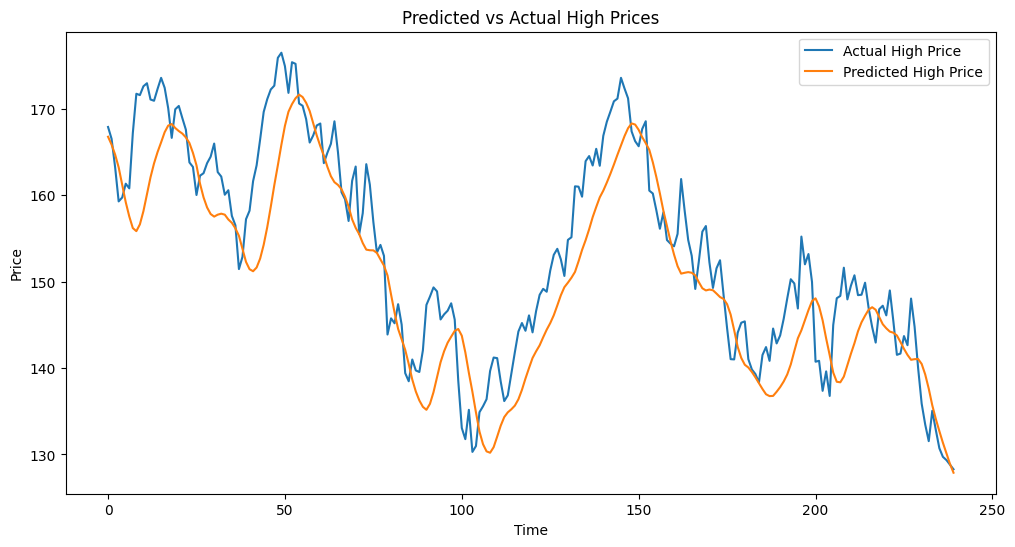

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices[:, 1], label='Actual High Price')     # Close is index 3
plt.plot(predicted_prices[:, 1], label='Predicted High Price')
plt.title('Predicted vs Actual High Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


<Figure size 1200x600 with 0 Axes>

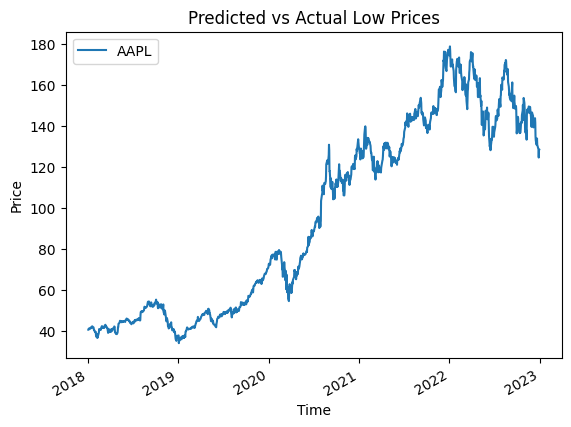

In [ ]:
plt.figure(figsize=(12,6))
# plt.plot(actual_prices[:, 2], label='Actual Low Price')
# plt.plot(predicted_prices[:, 1], label='Predicted High Price')
# plt.plot(predicted_prices[:, 2], label='Predicted Low Price')
# plt.plot(predicted_prices[:, 3], label='Predicted close Price')
plt.title('Predicted vs Actual Low Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


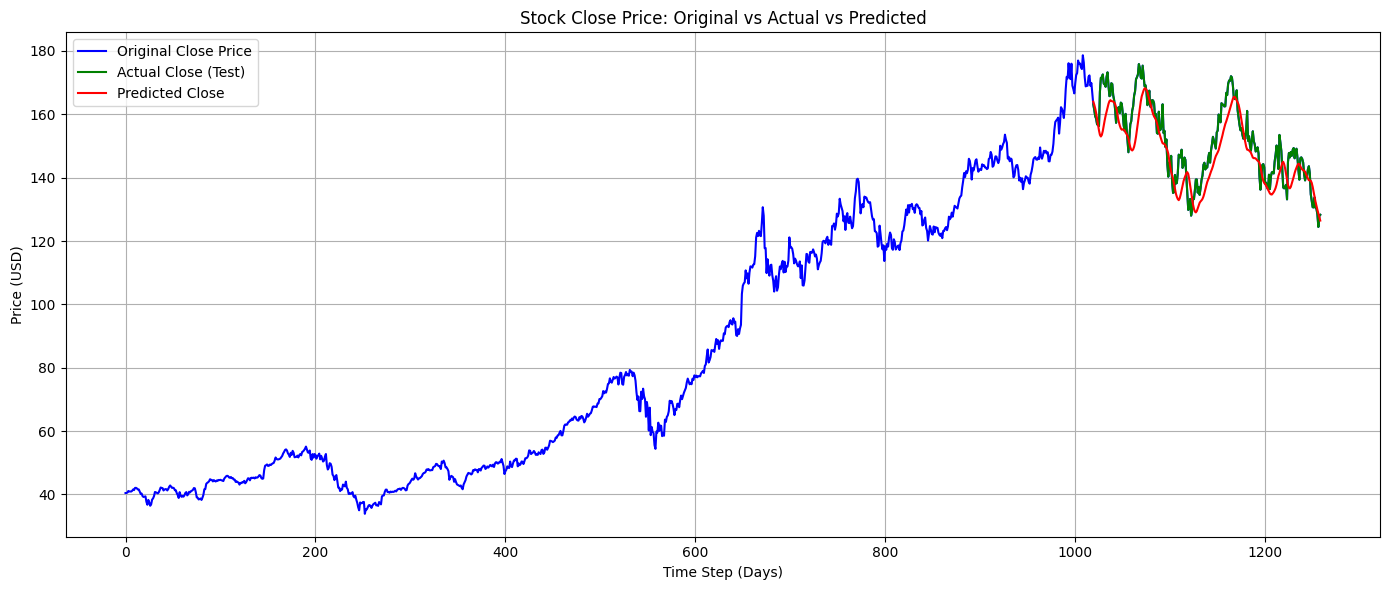

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot the original full close price series
plt.figure(figsize=(14, 6))
plt.plot(df['Close'].values, label="Original Close Price", color='blue')

# 2. Calculate offset where predictions begin
offset = seq_len + split  # because first seq_len rows are not used

# 3. Overlay actual close prices from test set
plt.plot(range(offset, offset + len(actual_prices)), actual_prices[:, 3], label="Actual Close (Test)", color='green')

# 4. Overlay predicted close prices
plt.plot(range(offset, offset + len(predicted_prices)), predicted_prices[:, 3], label="Predicted Close", color='red')

# 5. Formatting
plt.title("Stock Close Price: Original vs Actual vs Predicted")
plt.xlabel("Time Step (Days)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
